<a href="https://colab.research.google.com/github/khanzaifa37/SlotAttention-FG-BG/blob/main/BRISC_Baseline_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BRISC U-Net Baseline for Google Colab

This notebook downloads the BRISC segmentation dataset, builds a U-Net baseline, trains it, and visualizes sample predictions.

Recommended Colab runtime: `GPU`.

In [13]:
!pip -q install kagglehub pillow

In [ ]:
# === Mount Drive + clone tumor_seg package for shared model classes ===
from google.colab import drive
drive.mount('/content/drive')

import os, sys
REPO_DIR = '/content/SlotAttention-FG-BG'
if not os.path.exists(REPO_DIR):
    !git clone https://github.com/khanzaifa37/SlotAttention-FG-BG.git {REPO_DIR}
if f'{REPO_DIR}/tumor_seg' not in sys.path:
    sys.path.insert(0, f'{REPO_DIR}/tumor_seg')

BASELINE_RUNS_DIR = '/content/drive/MyDrive/baseline_runs'
UNET_OUT_DIR = f'{BASELINE_RUNS_DIR}/unet'
DINO_OUT_DIR = f'{BASELINE_RUNS_DIR}/dino_convtranspose'
os.makedirs(UNET_OUT_DIR, exist_ok=True)
os.makedirs(DINO_OUT_DIR, exist_ok=True)
print('UNet checkpoints  →', UNET_OUT_DIR)
print('DINO checkpoints  →', DINO_OUT_DIR)


## Kaggle authentication

If KaggleHub asks for credentials, run the next cell and upload your `kaggle.json` from Kaggle account settings.

In [14]:
import random
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from torch import nn
from torch.utils.data import DataLoader, Dataset, Subset

SEED = 42
IMAGE_SIZE = 224  # Changed from 128 to 224 for DINO-ViT compatibility
BATCH_SIZE = 8
EPOCHS = 10
TRAIN_LIMIT = None
VAL_LIMIT = None

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print('Using device:', DEVICE)

Using device: cuda


In [15]:
data_root = Path(kagglehub.dataset_download('briscdataset/brisc2025'))
print('Downloaded BRISC to:', data_root)

if (data_root / 'brisc2025' / 'segmentation_task').exists():
    segmentation_root = data_root / 'brisc2025' / 'segmentation_task'
elif (data_root / 'segmentation_task').exists():
    segmentation_root = data_root / 'segmentation_task'
else:
    raise FileNotFoundError(f'Could not find segmentation_task under {data_root}')

print('Segmentation root:', segmentation_root)

Using Colab cache for faster access to the 'brisc2025' dataset.
Downloaded BRISC to: /kaggle/input/brisc2025
Segmentation root: /kaggle/input/brisc2025/brisc2025/segmentation_task


In [16]:
import torchvision.transforms as T

class BriscSegmentationDataset(Dataset):
    def __init__(self, root, split, image_size=128, augment=False, rgb_input=False):
        self.root = Path(root)
        self.split = split
        self.image_size = image_size
        self.augment = augment
        self.rgb_input = rgb_input

        split_root = self.root / split
        self.images_dir = split_root / 'images'
        self.masks_dir = split_root / 'masks'

        if not self.images_dir.exists():
            raise FileNotFoundError(f'Images directory not found: {self.images_dir}')
        if not self.masks_dir.exists():
            raise FileNotFoundError(f'Masks directory not found: {self.masks_dir}')

        self.samples = []
        for image_path in sorted(self.images_dir.glob('*.jpg')):
            mask_path = self.masks_dir / f'{image_path.stem}.png'
            if mask_path.exists():
                self.samples.append((image_path, mask_path))

        if not self.samples:
            raise RuntimeError(f'No image/mask pairs found in {split_root}')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        image_path, mask_path = self.samples[index]

        if self.rgb_input:
            image = Image.open(image_path).convert('RGB').resize((self.image_size, self.image_size), Image.Resampling.BILINEAR)
            image_np = np.asarray(image, dtype=np.float32) / 255.0
            # Permute dimensions to C, H, W for RGB
            image_tensor = torch.from_numpy(image_np.transpose((2, 0, 1))).float()
        else:
            image = Image.open(image_path).convert('L').resize((self.image_size, self.image_size), Image.Resampling.BILINEAR)
            image_np = np.asarray(image, dtype=np.float32) / 255.0
            # Keep 1 channel for grayscale
            image_tensor = torch.from_numpy(image_np[None, ...]).float()

        mask = Image.open(mask_path).convert('L').resize((self.image_size, self.image_size), Image.Resampling.NEAREST)

        if self.augment:
            # Apply random horizontal flip
            if random.random() > 0.5:
                image = T.functional.hflip(image)
                mask = T.functional.hflip(mask)

            # Apply random vertical flip
            if random.random() > 0.5:
                image = T.functional.vflip(image)
                mask = T.functional.vflip(mask)

        # Re-convert to numpy arrays after augmentation for mask if image was augmented
        # For mask, always 1 channel
        mask_np = np.asarray(mask, dtype=np.float32)
        mask_np = (mask_np > 0).astype(np.float32)
        mask_tensor = torch.from_numpy(mask_np[None, ...]).float()

        # Re-convert image to tensor if augmented. It's simpler to do it here after all PIL transforms.
        if self.augment:
            if self.rgb_input:
                image_np = np.asarray(image, dtype=np.float32) / 255.0
                image_tensor = torch.from_numpy(image_np.transpose((2, 0, 1))).float()
            else:
                image_np = np.asarray(image, dtype=np.float32) / 255.0
                image_tensor = torch.from_numpy(image_np[None, ...]).float()

        return image_tensor, mask_tensor

def create_brisc_dataloaders(data_root, batch_size=8, image_size=128, train_limit=None, val_limit=None, augment_train=True, rgb_input=False):
    train_dataset = BriscSegmentationDataset(data_root, split='train', image_size=image_size, augment=augment_train, rgb_input=rgb_input)
    val_dataset = BriscSegmentationDataset(data_root, split='test', image_size=image_size, augment=False, rgb_input=rgb_input)

    if train_limit is not None:
        train_dataset = Subset(train_dataset, range(min(train_limit, len(train_dataset))))
    if val_limit is not None:
        val_dataset = Subset(val_dataset, range(min(val_limit, len(val_dataset))))

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    return train_loader, val_loader

In [17]:
import numpy as np
from scipy.spatial.distance import directed_hausdorff
import torch
from torch import nn
import torch.nn.functional as F

# UNet now lives in tumor_seg.baselines so 03_eval_viz.ipynb can reuse it.
from tumor_seg.baselines import UNet


def dice_coefficient(logits, targets, eps=1e-6):
    probs = torch.sigmoid(logits)
    probs = probs.flatten(1)
    targets = targets.flatten(1)
    intersection = (probs * targets).sum(dim=1)
    union = probs.sum(dim=1) + targets.sum(dim=1)
    return ((2 * intersection + eps) / (union + eps)).mean()

def iou_coefficient(logits, targets, eps=1e-6):
    probs = torch.sigmoid(logits)
    probs = probs.flatten(1)
    targets = targets.flatten(1)
    intersection = (probs * targets).sum(dim=1)
    union = probs.sum(dim=1) + targets.sum(dim=1) - intersection
    return ((intersection + eps) / (union + eps)).mean()

def hausdorff_distance_metric(logits, targets, threshold=0.5):
    global IMAGE_SIZE
    probs = torch.sigmoid(logits)
    predictions = (probs > threshold).float()
    predictions_np = predictions.cpu().numpy().squeeze()
    targets_np = targets.cpu().numpy().squeeze()
    batch_hd = []
    max_possible_dist = np.sqrt(2 * IMAGE_SIZE**2)
    for i in range(predictions_np.shape[0]):
        pred_mask = predictions_np[i]
        target_mask = targets_np[i]
        pred_coords = np.argwhere(pred_mask)
        target_coords = np.argwhere(target_mask)
        if pred_coords.size == 0 and target_coords.size == 0:
            hd = 0.0
        elif pred_coords.size == 0 or target_coords.size == 0:
            hd = max_possible_dist
        else:
            d1 = directed_hausdorff(pred_coords, target_coords)[0]
            d2 = directed_hausdorff(target_coords, pred_coords)[0]
            hd = max(d1, d2)
        batch_hd.append(hd)
    return np.mean(batch_hd)


class DiceBCELoss(nn.Module):
    def __init__(self, bce_weight=0.5):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.bce_weight = bce_weight

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)
        dice_loss = 1.0 - dice_coefficient(logits, targets)
        return self.bce_weight * bce_loss + (1.0 - self.bce_weight) * dice_loss


In [18]:
train_loader, val_loader = create_brisc_dataloaders(
    segmentation_root,
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE,
    train_limit=TRAIN_LIMIT,
    val_limit=VAL_LIMIT,
    augment_train=True # Enable augmentation for training data
)

print('Train samples:', len(train_loader.dataset))
print('Val samples:', len(val_loader.dataset))

sample_images, sample_masks = next(iter(train_loader))
print('Image batch shape:', sample_images.shape)
print('Mask batch shape:', sample_masks.shape)

Train samples: 3933
Val samples: 860
Image batch shape: torch.Size([8, 1, 224, 224])
Mask batch shape: torch.Size([8, 1, 224, 224])


In [19]:
def run_epoch(model, loader, criterion, device, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    total_loss = 0.0
    total_dice = 0.0
    total_iou = 0.0
    total_hd = 0.0 # Initialize total HD

    for images, masks in loader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            logits = model(images)
            loss = criterion(logits, masks)
            dice = dice_coefficient(logits, masks)
            iou = iou_coefficient(logits, masks)
            hd = hausdorff_distance_metric(logits, masks) # Calculate HD

        if is_train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * images.size(0)
        total_dice += dice.item() * images.size(0)
        total_iou += iou.item() * images.size(0)
        total_hd += hd * images.size(0) # Accumulate HD

    count = len(loader.dataset)
    return total_loss / count, total_dice / count, total_iou / count, total_hd / count # Return HD


model = UNet().to(DEVICE)
criterion = DiceBCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

history = []
for epoch in range(1, EPOCHS + 1):
    train_loss, train_dice, train_iou, train_hd = run_epoch(model, train_loader, criterion, DEVICE, optimizer=optimizer)
    val_loss, val_dice, val_iou, val_hd = run_epoch(model, val_loader, criterion, DEVICE)
    metrics = {
        'epoch': epoch,
        'train_loss': train_loss,
        'train_dice': train_dice,
        'train_iou': train_iou,
        'train_hd': train_hd, # Add train HD
        'val_loss': val_loss,
        'val_dice': val_dice,
        'val_iou': val_iou,
        'val_hd': val_hd, # Add val HD
    }
    history.append(metrics)
    print(metrics)

{'epoch': 1, 'train_loss': 0.493689313239188, 'train_dice': 0.19047552870409865, 'train_iou': 0.12263687375716026, 'train_hd': np.float64(116.90533411686408), 'val_loss': 0.3739055715328039, 'val_dice': 0.3819953938556272, 'val_iou': 0.26544796370489654, 'val_hd': np.float64(78.43146191831327)}
{'epoch': 2, 'train_loss': 0.2744006241115031, 'train_dice': 0.514868990901527, 'train_iou': 0.3972354915164489, 'train_hd': np.float64(53.241949753337735), 'val_loss': 0.2583970635436302, 'val_dice': 0.5594009325254795, 'val_iou': 0.4367952885322793, 'val_hd': np.float64(54.25594506456678)}
{'epoch': 3, 'train_loss': 0.23793996189679015, 'train_dice': 0.582408879387024, 'train_iou': 0.46629197051771837, 'train_hd': np.float64(45.87930816294122), 'val_loss': 0.2191519507488539, 'val_dice': 0.6204972049524617, 'val_iou': 0.5032846231100171, 'val_hd': np.float64(45.39948969697678)}
{'epoch': 4, 'train_loss': 0.20899416759757938, 'train_dice': 0.6344732794405818, 'train_iou': 0.5199563180691045, 't

In [20]:
ckpt = {
    'arch': 'unet',
    'epoch': len(history),
    'in_channels': 1,
    'image_size': IMAGE_SIZE,
    'history': history,
    'model': model.state_dict(),
}
torch.save(ckpt, f'{UNET_OUT_DIR}/best_model.pt')
print('Saved UNet checkpoint to', f'{UNET_OUT_DIR}/best_model.pt')


Saved checkpoint to brisc_unet_baseline.pt


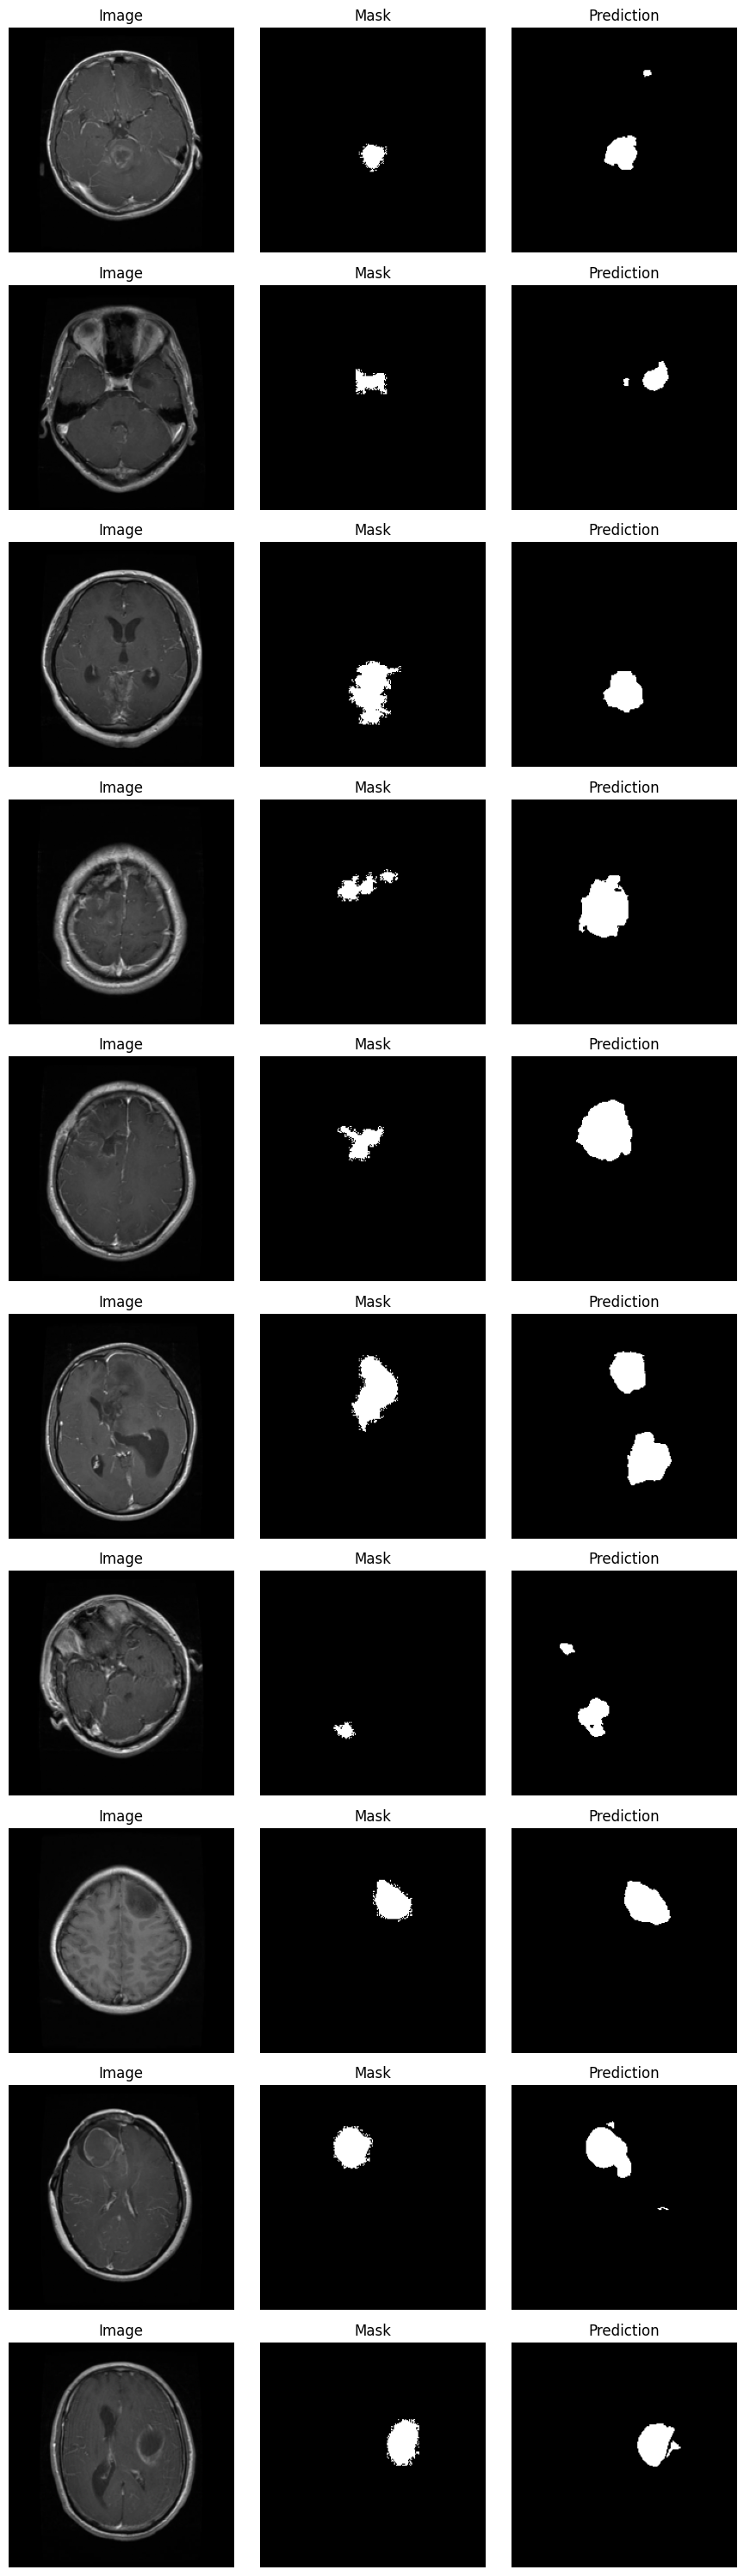

In [21]:
model.eval()
all_images = []
all_masks = []
all_preds = []

# Collect a few batches to get more images for random sampling
num_batches_to_collect = 5
with torch.no_grad():
    for batch_idx, (images_batch, masks_batch) in enumerate(val_loader):
        if batch_idx >= num_batches_to_collect:
            break
        images_batch = images_batch.to(DEVICE)
        masks_batch = masks_batch.to(DEVICE)

        logits_batch = model(images_batch)
        preds_batch = (torch.sigmoid(logits_batch) > 0.5).float().cpu()

        all_images.append(images_batch.cpu())
        all_masks.append(masks_batch.cpu())
        all_preds.append(preds_batch)

# Concatenate all collected data
all_images = torch.cat(all_images, dim=0)
all_masks = torch.cat(all_masks, dim=0)
all_preds = torch.cat(all_preds, dim=0)

# Get random indices for displaying up to 10 images
num_available_images = all_images.size(0)
num_show = min(10, num_available_images)

# Generate random indices
random_indices = random.sample(range(num_available_images), num_show)

fig, axes = plt.subplots(num_show, 3, figsize=(9, 3 * num_show))
if num_show == 1:
    axes = np.expand_dims(axes, axis=0)

for i, idx in enumerate(random_indices):
    axes[i, 0].imshow(all_images[idx, 0], cmap='gray')
    axes[i, 0].set_title('Image')
    axes[i, 1].imshow(all_masks[idx, 0], cmap='gray')
    axes[i, 1].set_title('Mask')
    axes[i, 2].imshow(all_preds[idx, 0], cmap='gray')
    axes[i, 2].set_title('Prediction')
    for j in range(3):
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()

In [22]:
# DinoViTSegmentationModel now lives in tumor_seg.baselines so 03_eval_viz.ipynb
# can reuse it.
from tumor_seg.baselines import DinoViTSegmentationModel


In [ ]:
from tumor_seg.baselines import build_dino_baseline

dino_seg_model = build_dino_baseline(image_size=IMAGE_SIZE, out_channels=1).to(DEVICE)
print('DINO-ViT segmentation model instantiated.')


Now that we have both the U-Net baseline and the DINO-ViT based segmentation model defined, we can proceed with training and comparing them. The next steps would be:

1.  **Define a new training loop function** or adapt the existing `run_epoch` to specifically train `dino_seg_model`.
2.  **Set up optimizer and loss function** for the new model.
3.  **Train the `dino_seg_model`** for a number of epochs.
4.  **Visualize predictions** from the `dino_seg_model`.
5.  **Compare the performance metrics** (loss, Dice, IoU, HD) of both models to evaluate which one performs better on this dataset.

In [24]:
# Install the timm library for Vision Transformers
!pip -q install timm

In [ ]:
from tumor_seg.baselines import build_dino_baseline

dino_seg_model = build_dino_baseline(image_size=IMAGE_SIZE, out_channels=1).to(DEVICE)
print('DINO-ViT segmentation model instantiated.')


In [27]:
dino_train_loader, dino_val_loader = create_brisc_dataloaders(
    segmentation_root,
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE,
    train_limit=TRAIN_LIMIT,
    val_limit=VAL_LIMIT,
    augment_train=True,
    rgb_input=True # Crucial for DINO-ViT
)

print('DINO Train samples:', len(dino_train_loader.dataset))
print('DINO Val samples:', len(dino_val_loader.dataset))

sample_images_dino, sample_masks_dino = next(iter(dino_train_loader))
print('DINO Image batch shape:', sample_images_dino.shape)
print('DINO Mask batch shape:', sample_masks_dino.shape)

DINO Train samples: 3933
DINO Val samples: 860
DINO Image batch shape: torch.Size([8, 3, 224, 224])
DINO Mask batch shape: torch.Size([8, 1, 224, 224])


Now that we have the DINO-pretrained Vision Transformer encoder, the next crucial step is to build a decoder that can take the features extracted by this ViT and upsample them to produce a segmentation mask of the original image size (128x128).

This typically involves:
1.  **Extracting multi-scale features** from the ViT encoder (as ViTs produce a single sequence of tokens, this often requires careful consideration or using architectures designed for dense prediction, like a UperNet head or a simple convolutional decoder).
2.  **Designing a decoder** (e.g., using transposed convolutions or attention-based upsampling) to progressively reconstruct the segmentation mask.
3.  **Adapting input preprocessing** to match the DINO pre-training (e.g., mean/std normalization, image size typically 224x224).

This setup is more complex and would require defining a new `nn.Module` class that wraps the DINO encoder and adds a suitable decoder for segmentation. Would you like me to outline a basic structure for such a model, or do you have a specific DINO-based segmentation architecture in mind?

In [28]:
dino_model = dino_seg_model # Use the instantiated DINO model
dino_criterion = DiceBCELoss()
dino_optimizer = torch.optim.Adam(dino_model.parameters(), lr=1e-4) # Slightly lower LR for pre-trained model

dino_history = []
print('Starting DINO model training...')
for epoch in range(1, EPOCHS + 1):
    train_loss, train_dice, train_iou, train_hd = run_epoch(dino_model, dino_train_loader, dino_criterion, DEVICE, optimizer=dino_optimizer)
    val_loss, val_dice, val_iou, val_hd = run_epoch(dino_model, dino_val_loader, dino_criterion, DEVICE)
    metrics = {
        'epoch': epoch,
        'train_loss': train_loss,
        'train_dice': train_dice,
        'train_iou': train_iou,
        'train_hd': train_hd,
        'val_loss': val_loss,
        'val_dice': val_dice,
        'val_iou': val_iou,
        'val_hd': val_hd,
    }
    dino_history.append(metrics)
    print(metrics)

ckpt = {
    'arch': 'dino_convtranspose',
    'epoch': len(dino_history),
    'in_channels': 3,
    'image_size': IMAGE_SIZE,
    'history': dino_history,
    'model': dino_model.state_dict(),
}
torch.save(ckpt, f'{DINO_OUT_DIR}/best_model.pt')
print('Saved DINO checkpoint to', f'{DINO_OUT_DIR}/best_model.pt')

Starting DINO model training...
{'epoch': 1, 'train_loss': 0.3947306543384046, 'train_dice': 0.3424263739673776, 'train_iou': 0.23813739160969455, 'train_hd': np.float64(86.5690998951647), 'val_loss': 0.23983033216276833, 'val_dice': 0.5786719345769217, 'val_iou': 0.4332168612369271, 'val_hd': np.float64(20.776448740783362)}
{'epoch': 2, 'train_loss': 0.2280435003292885, 'train_dice': 0.5967976972100816, 'train_iou': 0.4547511751024953, 'train_hd': np.float64(21.74630275103395), 'val_loss': 0.2003017547518708, 'val_dice': 0.6443768473558648, 'val_iou': 0.5026989559794581, 'val_hd': np.float64(18.598757033631117)}
{'epoch': 3, 'train_loss': 0.1914417366702048, 'train_dice': 0.6606574440287356, 'train_iou': 0.5195173520245323, 'train_hd': np.float64(17.245363673368665), 'val_loss': 0.1850883683492971, 'val_dice': 0.6739088809767435, 'val_iou': 0.5349322526953941, 'val_hd': np.float64(15.906762698430445)}
{'epoch': 4, 'train_loss': 0.16368533848026404, 'train_dice': 0.7095034654559357, 't

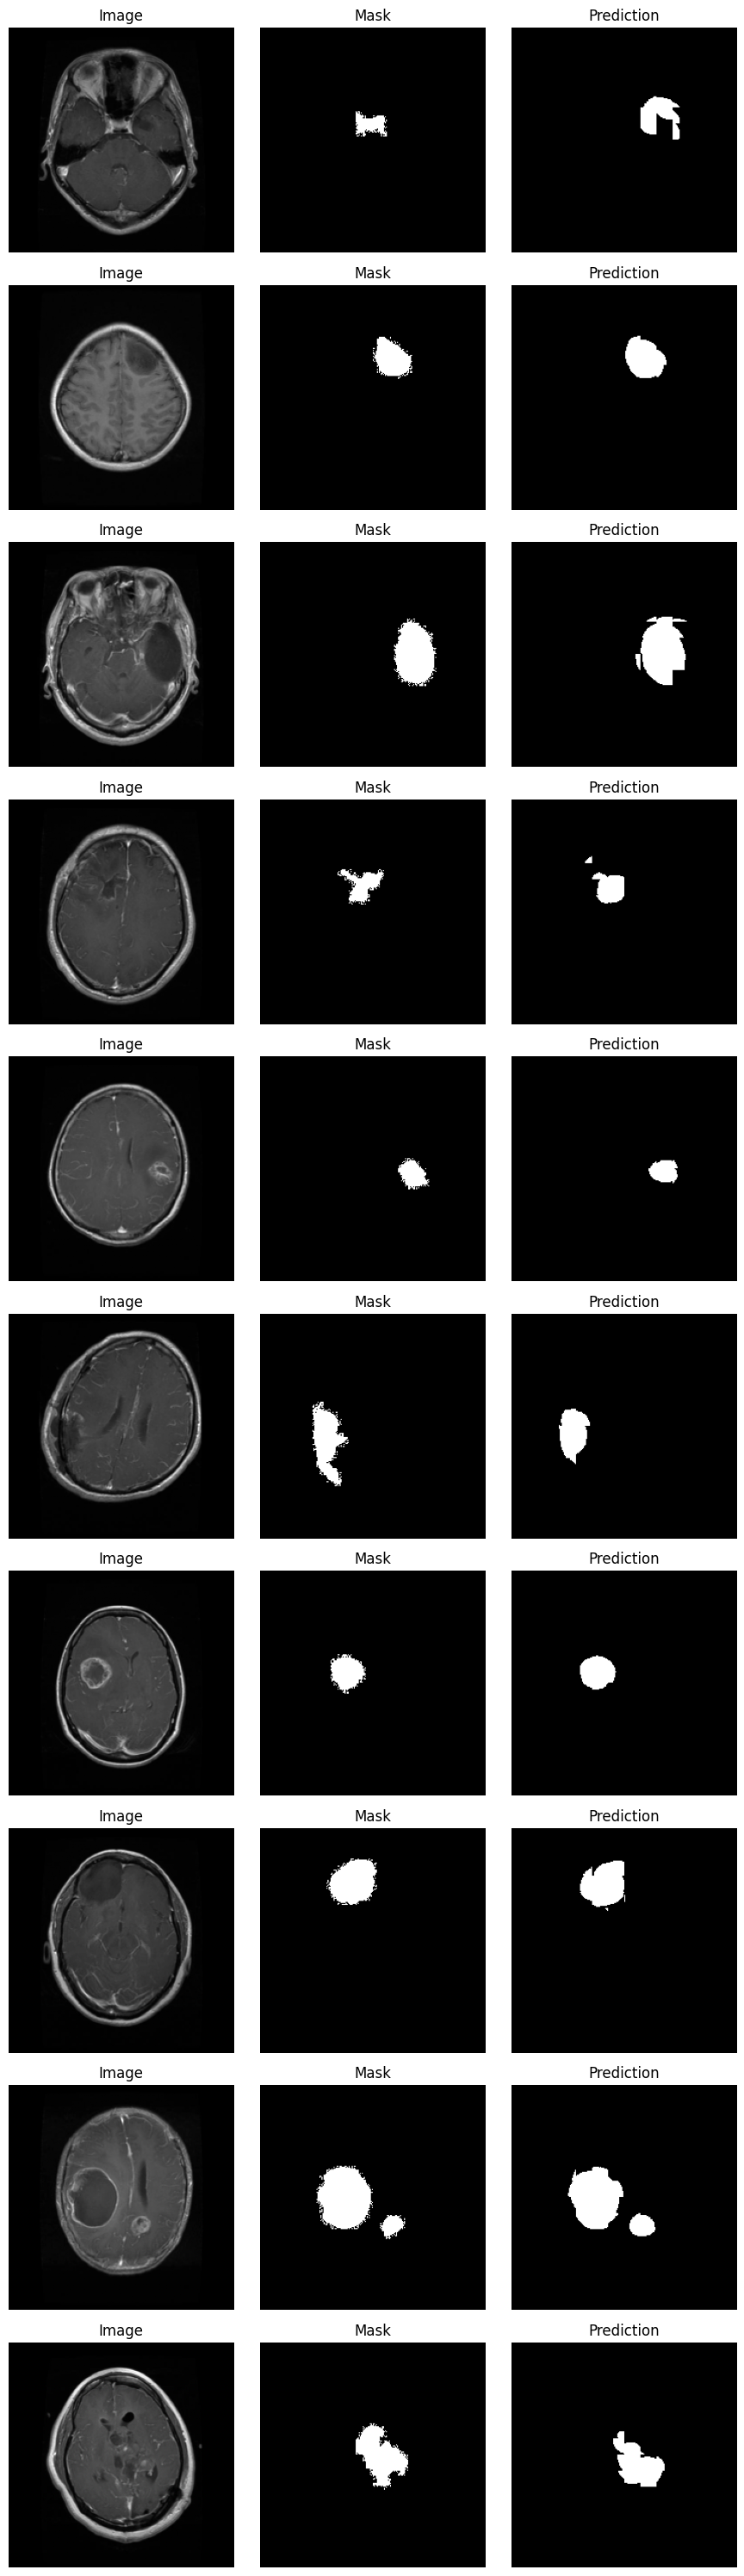

In [29]:
dino_model.eval()
all_images_dino = []
all_masks_dino = []
all_preds_dino = []

# Collect a few batches to get more images for random sampling
num_batches_to_collect = 5
with torch.no_grad():
    for batch_idx, (images_batch, masks_batch) in enumerate(dino_val_loader):
        if batch_idx >= num_batches_to_collect:
            break
        images_batch = images_batch.to(DEVICE)
        masks_batch = masks_batch.to(DEVICE)

        logits_batch = dino_model(images_batch)
        preds_batch = (torch.sigmoid(logits_batch) > 0.5).float().cpu()

        all_images_dino.append(images_batch.cpu())
        all_masks_dino.append(masks_batch.cpu())
        all_preds_dino.append(preds_batch)

# Concatenate all collected data
all_images_dino = torch.cat(all_images_dino, dim=0)
all_masks_dino = torch.cat(all_masks_dino, dim=0)
all_preds_dino = torch.cat(all_preds_dino, dim=0)

# Get random indices for displaying up to 10 images
num_available_images_dino = all_images_dino.size(0)
num_show = min(10, num_available_images_dino)

# Generate random indices
random_indices_dino = random.sample(range(num_available_images_dino), num_show)

fig, axes = plt.subplots(num_show, 3, figsize=(9, 3 * num_show))
if num_show == 1:
    axes = np.expand_dims(axes, axis=0)

for i, idx in enumerate(random_indices_dino):
    # For DINO, images are RGB (3 channels), so we show the first channel or convert to grayscale for display
    # Or, if we want to show RGB, adjust imshow for 3 channels.
    # Since the original images were grayscale converted to RGB for DINO, showing one channel is fine.
    axes[i, 0].imshow(all_images_dino[idx, 0], cmap='gray') # Displaying one channel as grayscale
    axes[i, 0].set_title('Image')
    axes[i, 1].imshow(all_masks_dino[idx, 0], cmap='gray')
    axes[i, 1].set_title('Mask')
    axes[i, 2].imshow(all_preds_dino[idx, 0], cmap='gray')
    axes[i, 2].set_title('Prediction')
    for j in range(3):
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()